## This should be more or less the same Q-Q-plot result as in dataprep!

In [1]:
import statsmodels.api as sm
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../houses_fixed.csv")
df.head(5)

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,2014-10-13,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,2014-12-09,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,2015-02-25,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,2014-12-09,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,2015-02-18,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


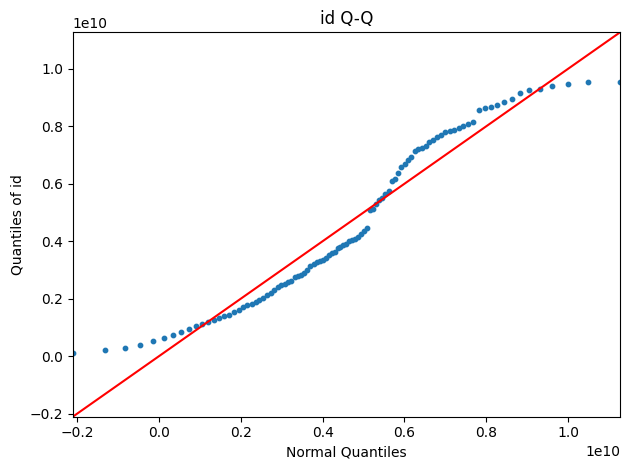

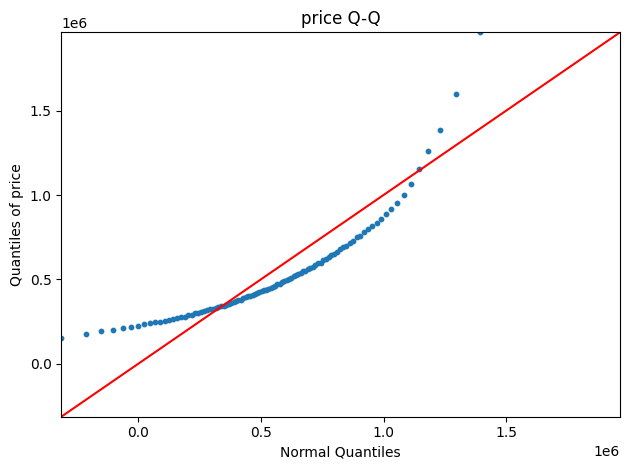

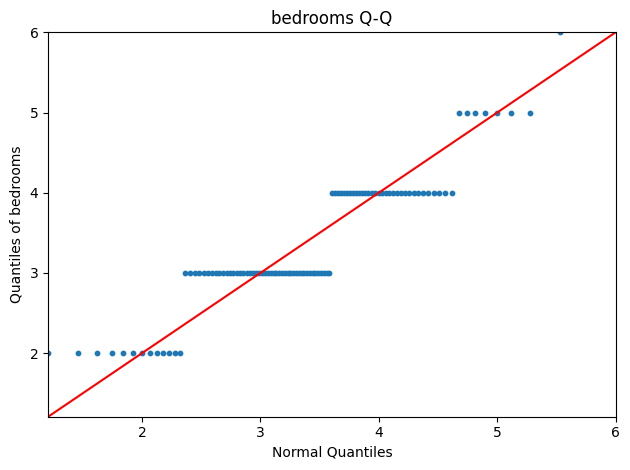

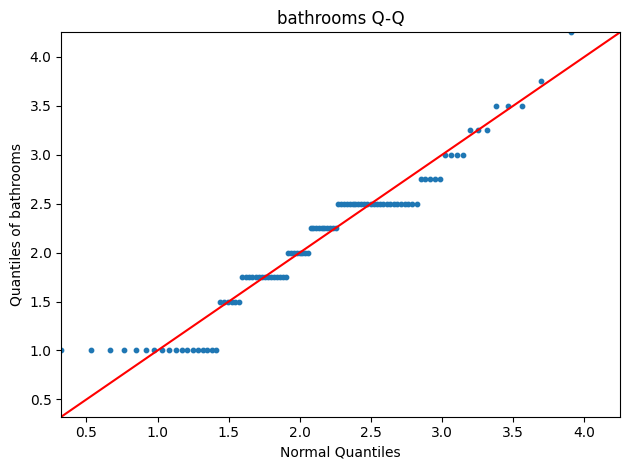

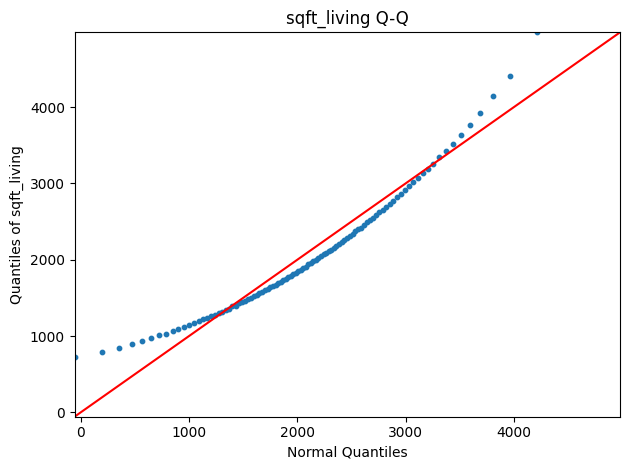

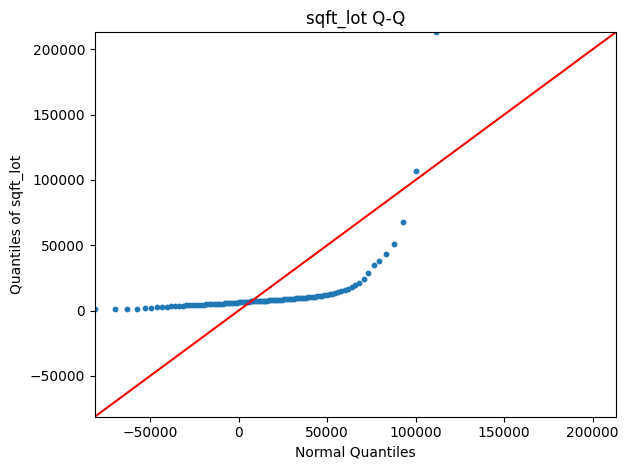

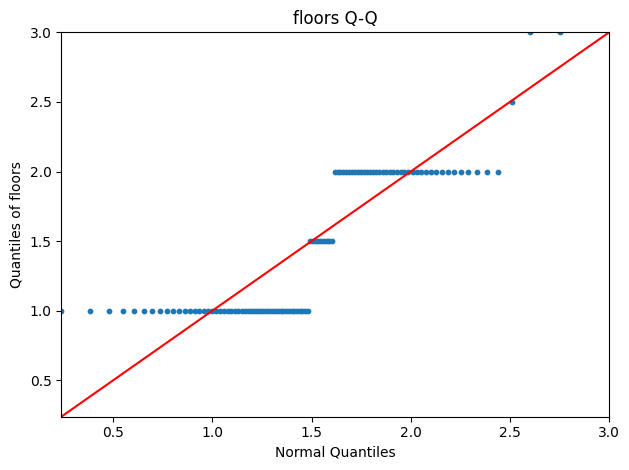

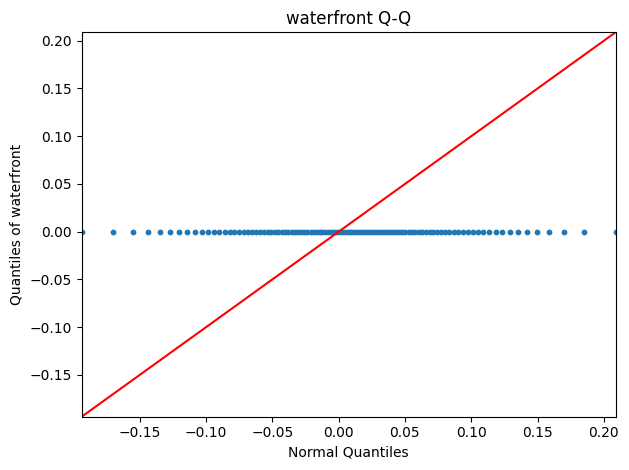

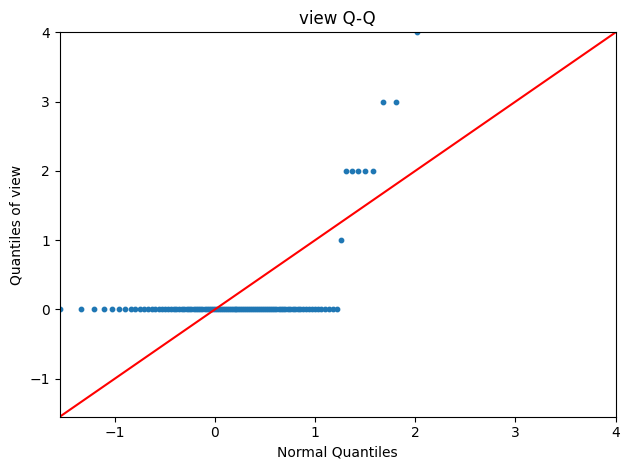

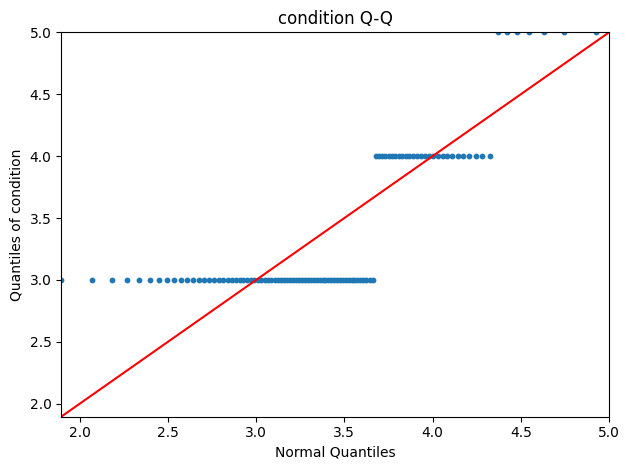

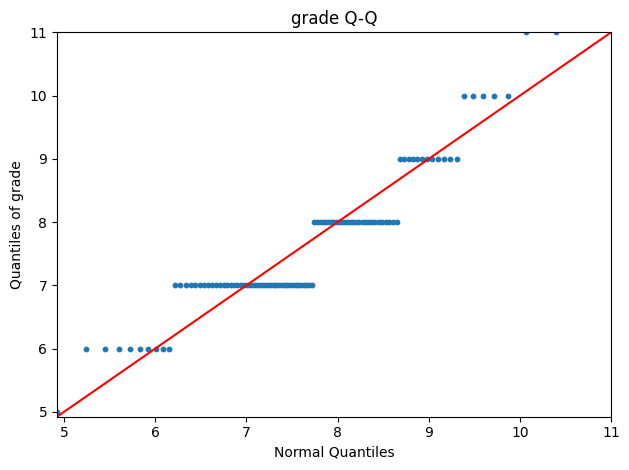

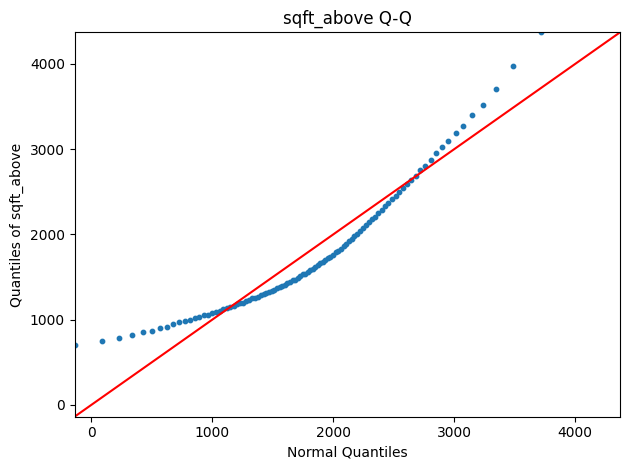

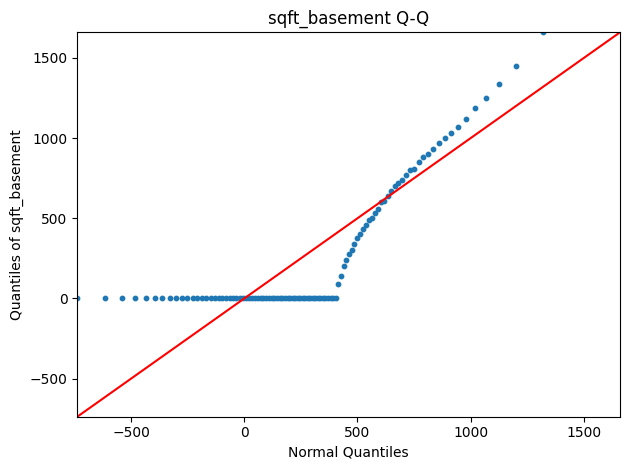

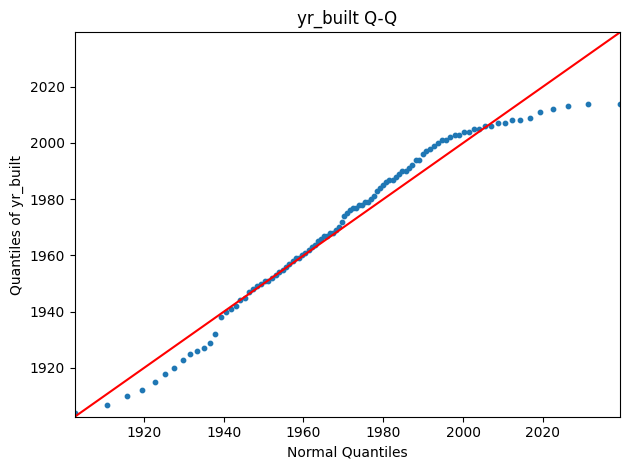

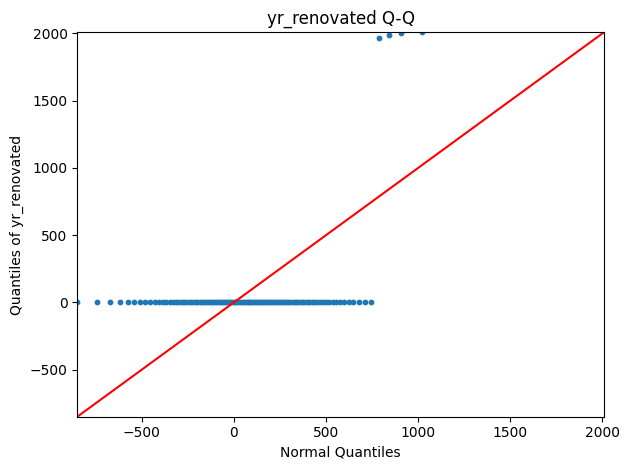

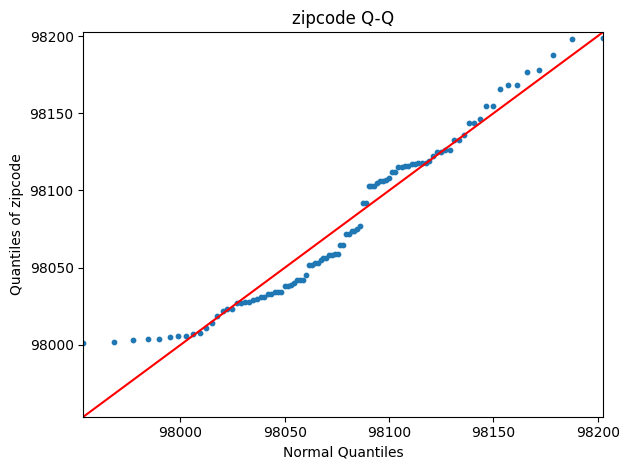

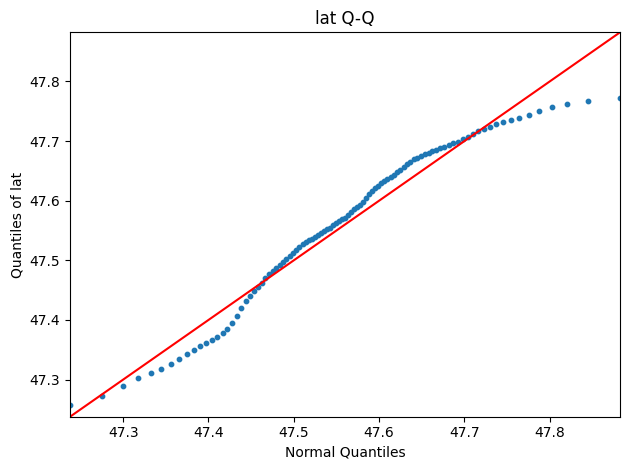

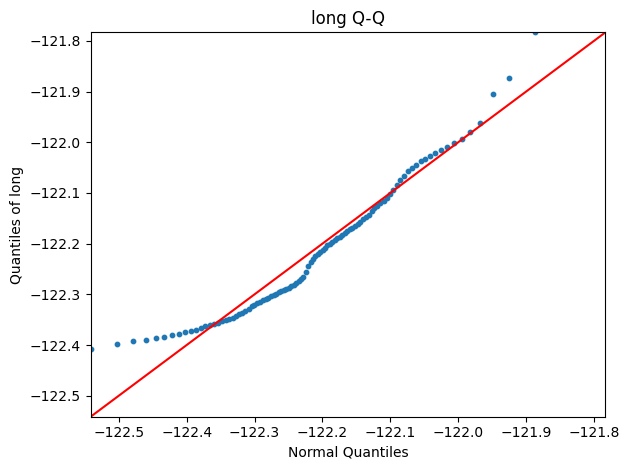

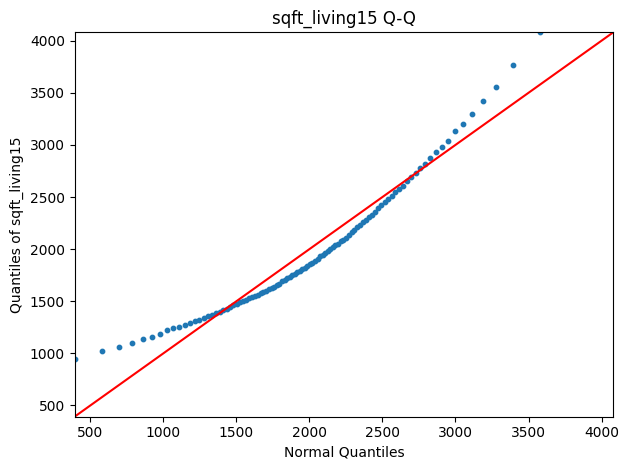

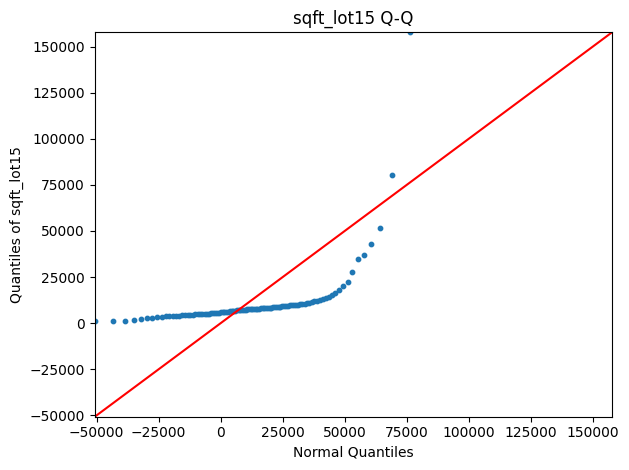

In [2]:
# This snippet displays the Q-Q plots for each numeric column!

import numpy as np
from scipy.stats import norm
import matplotlib.pyplot as plt

for column in df.columns:

    # Get rid of any non-numerical columns.
    if pd.api.types.is_numeric_dtype(df[column]):

        # Drop missing values in case it causes problems
        values = df[column].dropna()

        # Fit a normal distribution to THIS column's own scale.
        mean, std = values.mean(), values.std()

        # Make 99 percentiles, evenly spaced.
        probs = np.linspace(0.01, 0.99, 99)

        # Copies dataprep's method. take the sample of the quantiles.
        sample_qntls = values.quantile(probs)

        # Theoretical quantiles: what a perfectly normal distribution with
        # the datas mean and std would look like at each %
        theory_qntls = norm.ppf(probs, mean, std)

        # Combine both sets to find a shared min/max.
        vals = np.concatenate([sample_qntls, theory_qntls])
        lo, hi = vals.min(), vals.max()
        fig, ax = plt.subplots()

        # Plot sample quantiles with theoretical quantiles.
        ax.scatter(theory_qntls, sample_qntls, s=10)

        # Draw a diagonal line.
        ax.plot([lo, hi], [lo, hi], color="r")

        # Force both axes to the same range. Makes the 45 degrees fixed.
        ax.set_xlim(lo, hi)
        ax.set_ylim(lo, hi)

        ax.set_title(f"{column} Q-Q")
        ax.set_xlabel("Normal Quantiles")
        ax.set_ylabel(f"Quantiles of {column}")

        plt.tight_layout()
        plt.show()